In [1]:
import pathlib

import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns

from rdkit import Chem
from matplotlib import pyplot as plt

from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from krfp_models import krfp_models
from mpnn import MoleculeODetector, mol_to_torch
from xai_methods import PGExplainerAttributionMethod

In [10]:
pge: PGExplainerAttributionMethod = torch.load(
    "artifacts/explainability_method_tester/R2/MoleculeODetector/PG Explainer_explainer.pt",
    weights_only=False)

pge_r1: PGExplainerAttributionMethod = torch.load(
    "artifacts/explainability_method_tester/R1/MoleculeODetector/PG Explainer_explainer.pt",
    weights_only=False
)

r1_results = pd.read_csv(
    "artifacts/explainability_method_tester/R1/MoleculeODetector/negative_explainability_results.csv"
)

r2_results = pd.read_csv(
    "artifacts/explainability_method_tester/R2/MoleculeODetector/negative_explainability_results.csv"
)

assert r1_results["PG Explainer"].tolist() == r2_results["PG Explainer"].tolist()

pge_fails = r2_results[r2_results["PG Explainer"] == False]
pge_fails = pge_fails["SMILES"].tolist()

In [15]:
pge_mlp = pge.explainer.algorithm.mlp


class MLPWrapper(torch.nn.Module):
    def __init__(self, mlp: torch.nn.Module):
        super().__init__()
        self.mlp = mlp

    def forward(self, x):
        print("X", x)
        output = self.mlp(x)
        print("Output", output)
        return output


wrapper = MLPWrapper(pge_mlp)
pge.explainer.algorithm.mlp = wrapper

pge_r1_mlp = pge_r1.explainer.algorithm.mlp
wrapper_r1 = MLPWrapper(pge_r1_mlp)

In [12]:
def show_pge_attrib(smile: str):
    mol = Chem.MolFromSmiles(smile)

    model = MoleculeODetector()
    x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

    node_attrs, edge_attrs = pge.explain(
        example_x=x,
        example_e=edge_features,
        edge_index=edge_index
    )

    node_attrs = node_attrs.squeeze().detach().numpy().tolist()

    print("Model prediction:", model(x, edge_features, edge_index).item())

    return visualize_atom_importance_from_mol(
        mol=mol,
        attributions=node_attrs,
        length=1000,
        precision=2,
        bond_line_width=2
    )


def show_pge_attrib_r1(smile: str):
    mol = Chem.MolFromSmiles(smile)

    model = MoleculeODetector()
    x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

    node_attrs, edge_attrs = pge_r1.explain(
        example_x=x,
        example_e=edge_features,
        edge_index=edge_index
    )

    node_attrs = node_attrs.squeeze().detach().numpy().tolist()

    print("Model prediction:", model(x, edge_features, edge_index).item())

    return visualize_atom_importance_from_mol(
        mol=mol,
        attributions=node_attrs,
        length=1000,
        precision=2,
        bond_line_width=2
    )

X tensor([[0., 0., 0., 1.],
        [0., 1., 0., 0.],
        [0., 1., 0., 1.],
        [0., 1., 0., 1.],
        [0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0

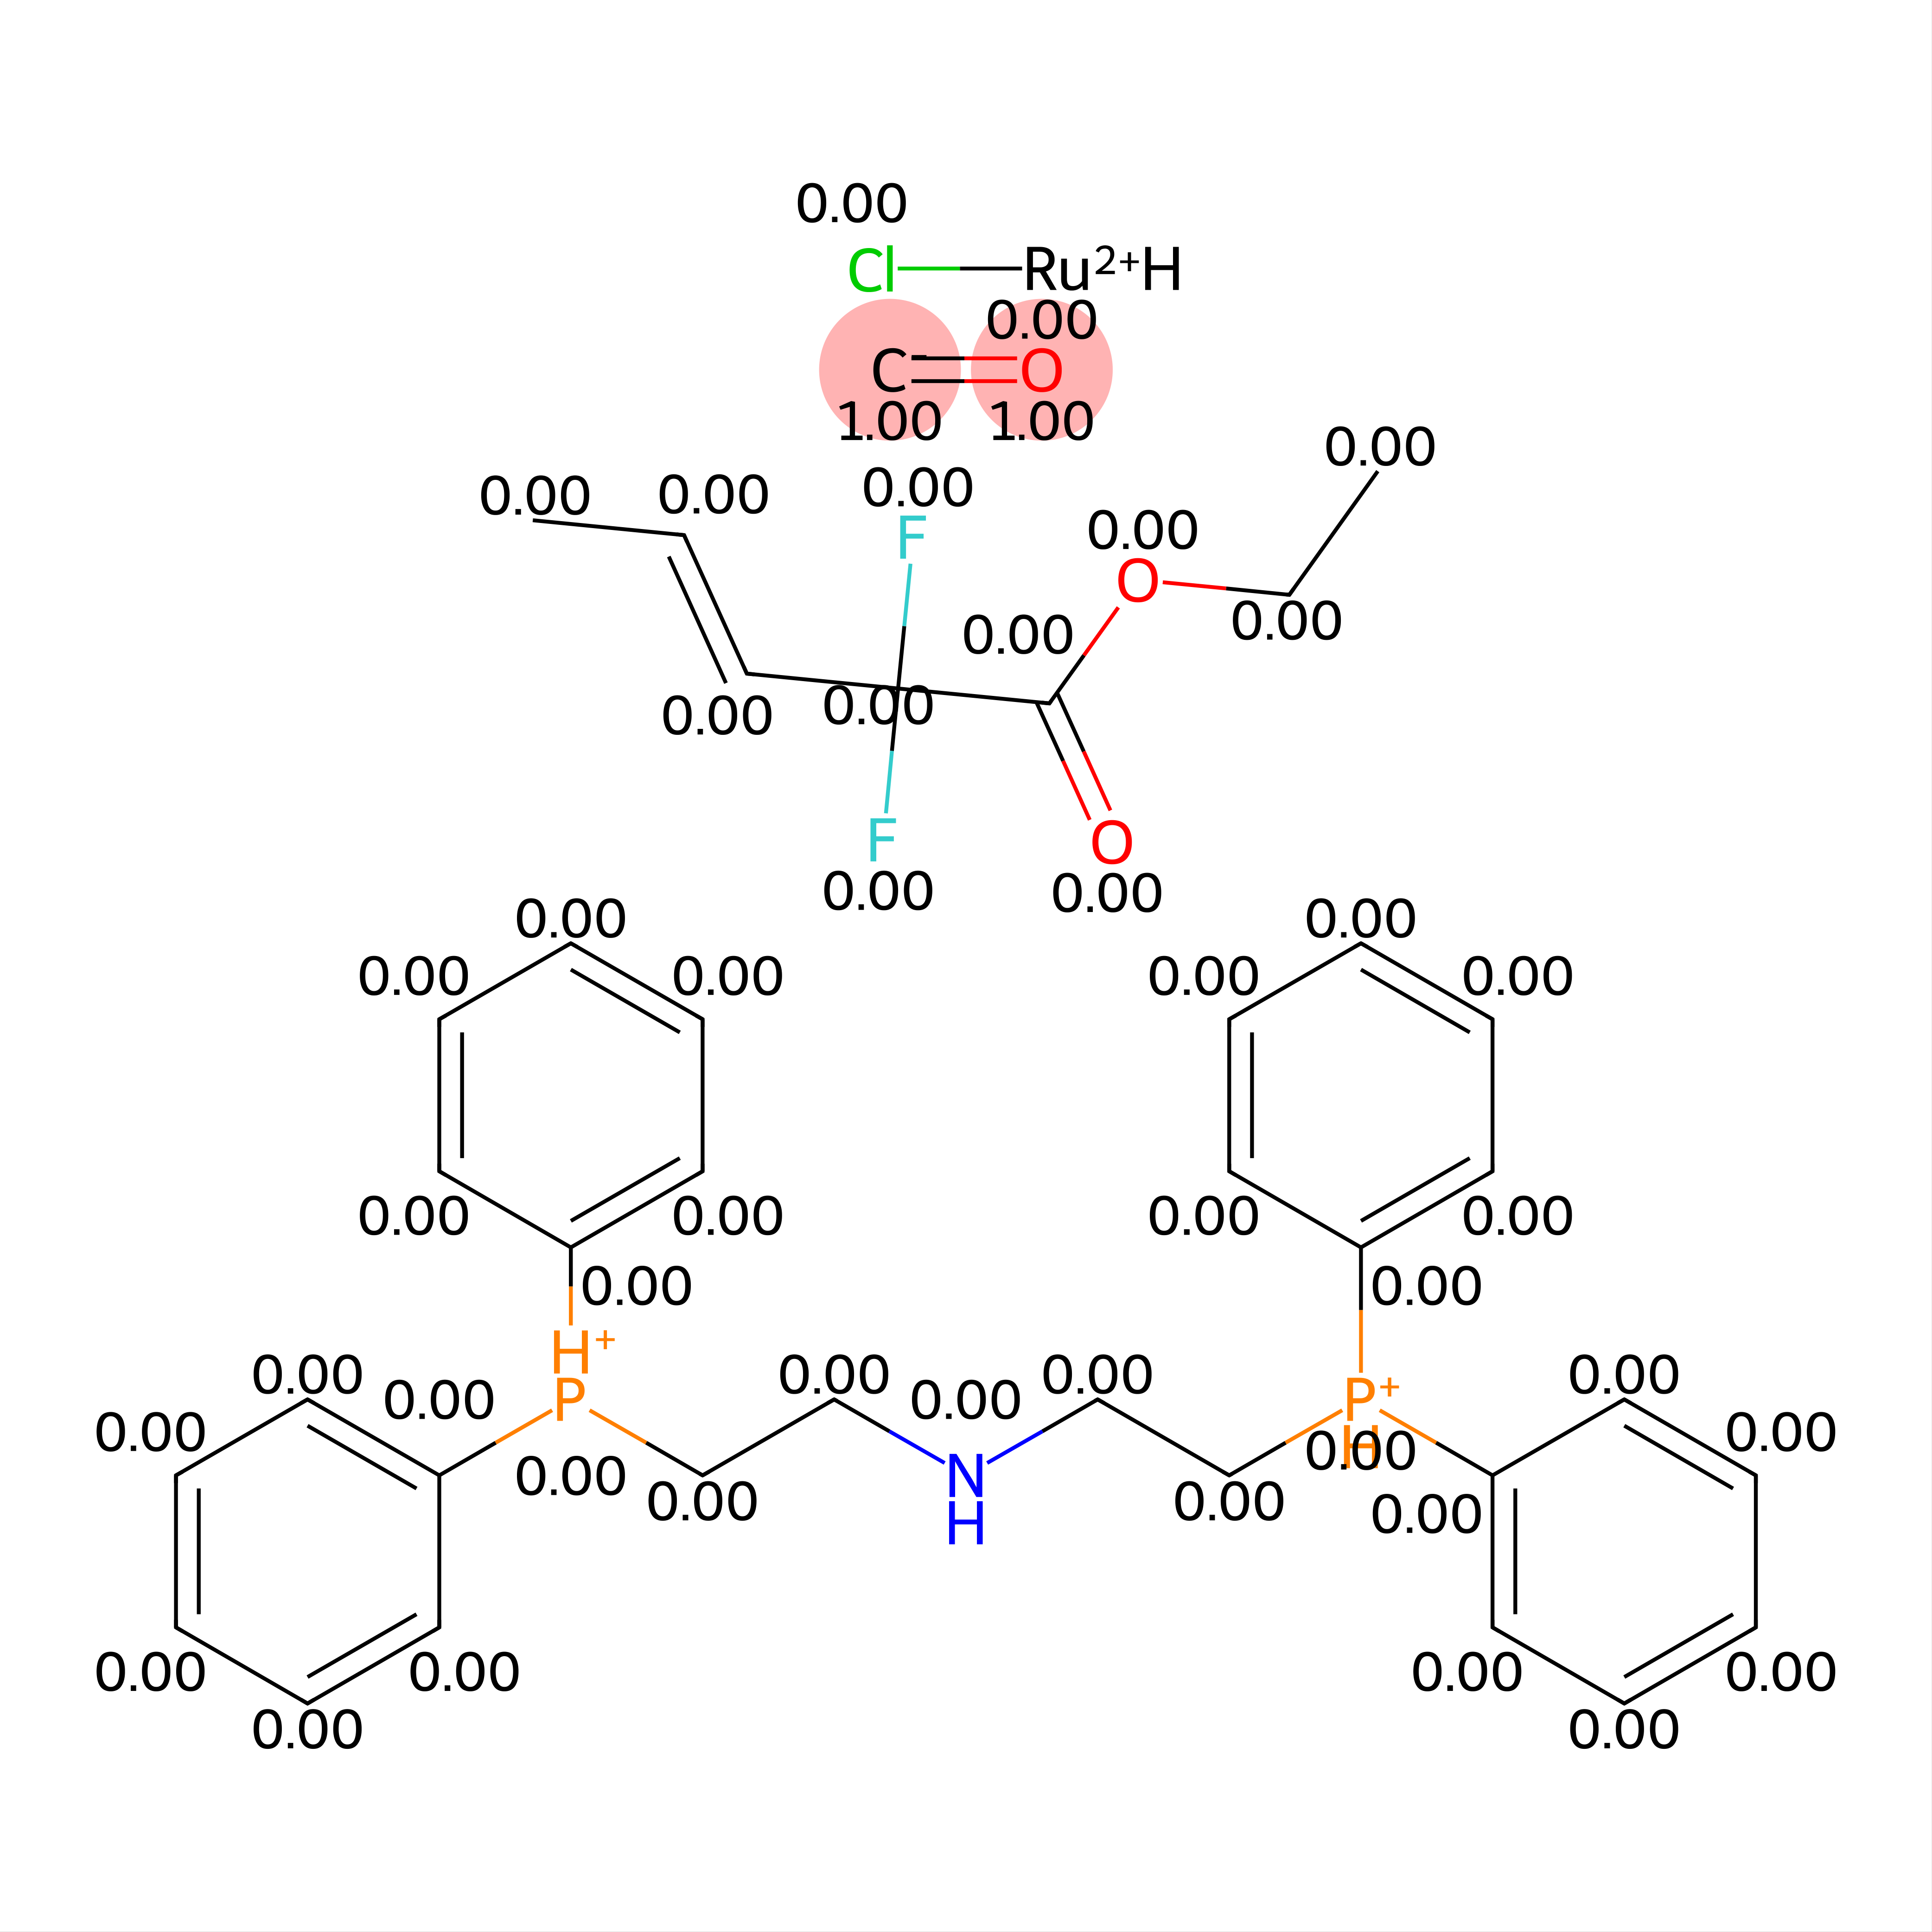

In [13]:
fail_smile = pge_fails[0]

show_pge_attrib(fail_smile)

Model prediction: 0.0


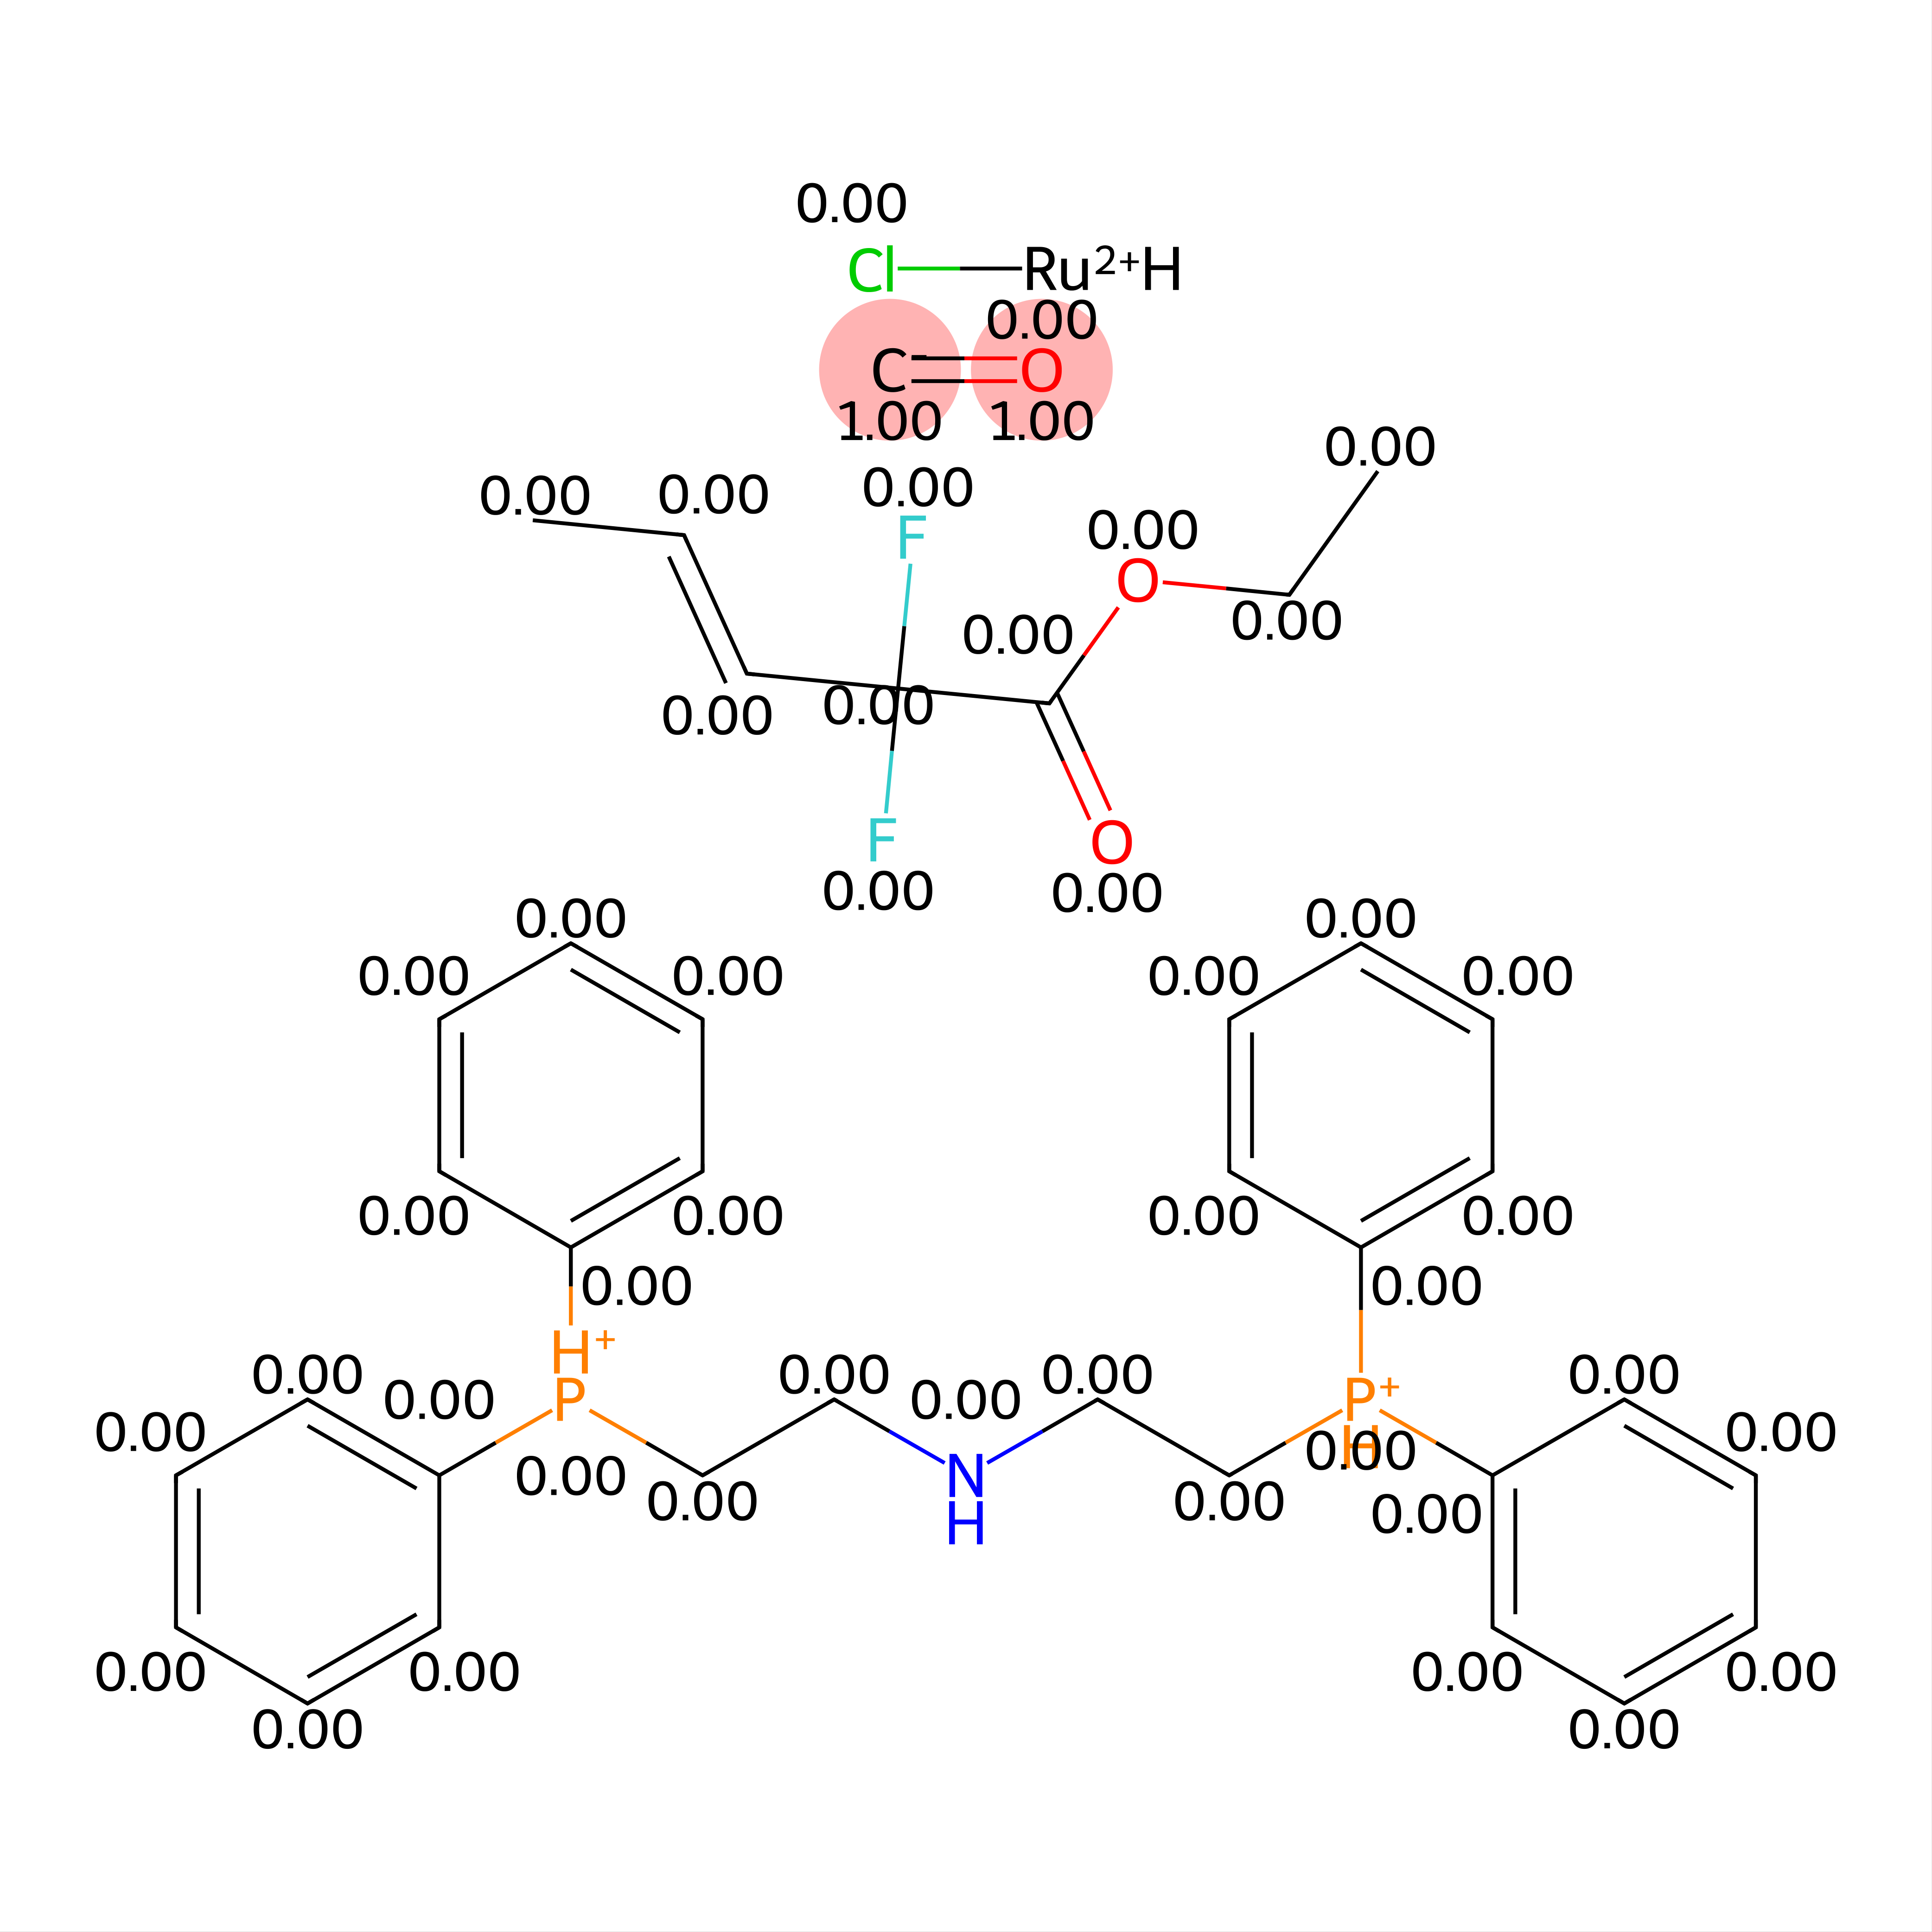

In [14]:
fail_smile = pge_fails[0]

show_pge_attrib_r1(fail_smile)

X tensor([[1., 0., 0., 0.],
        [0., 0., 1., 0.]])
Output tensor([[-132.7311],
        [  54.3744]], grad_fn=<AddmmBackward0>)
Model prediction: 0.0


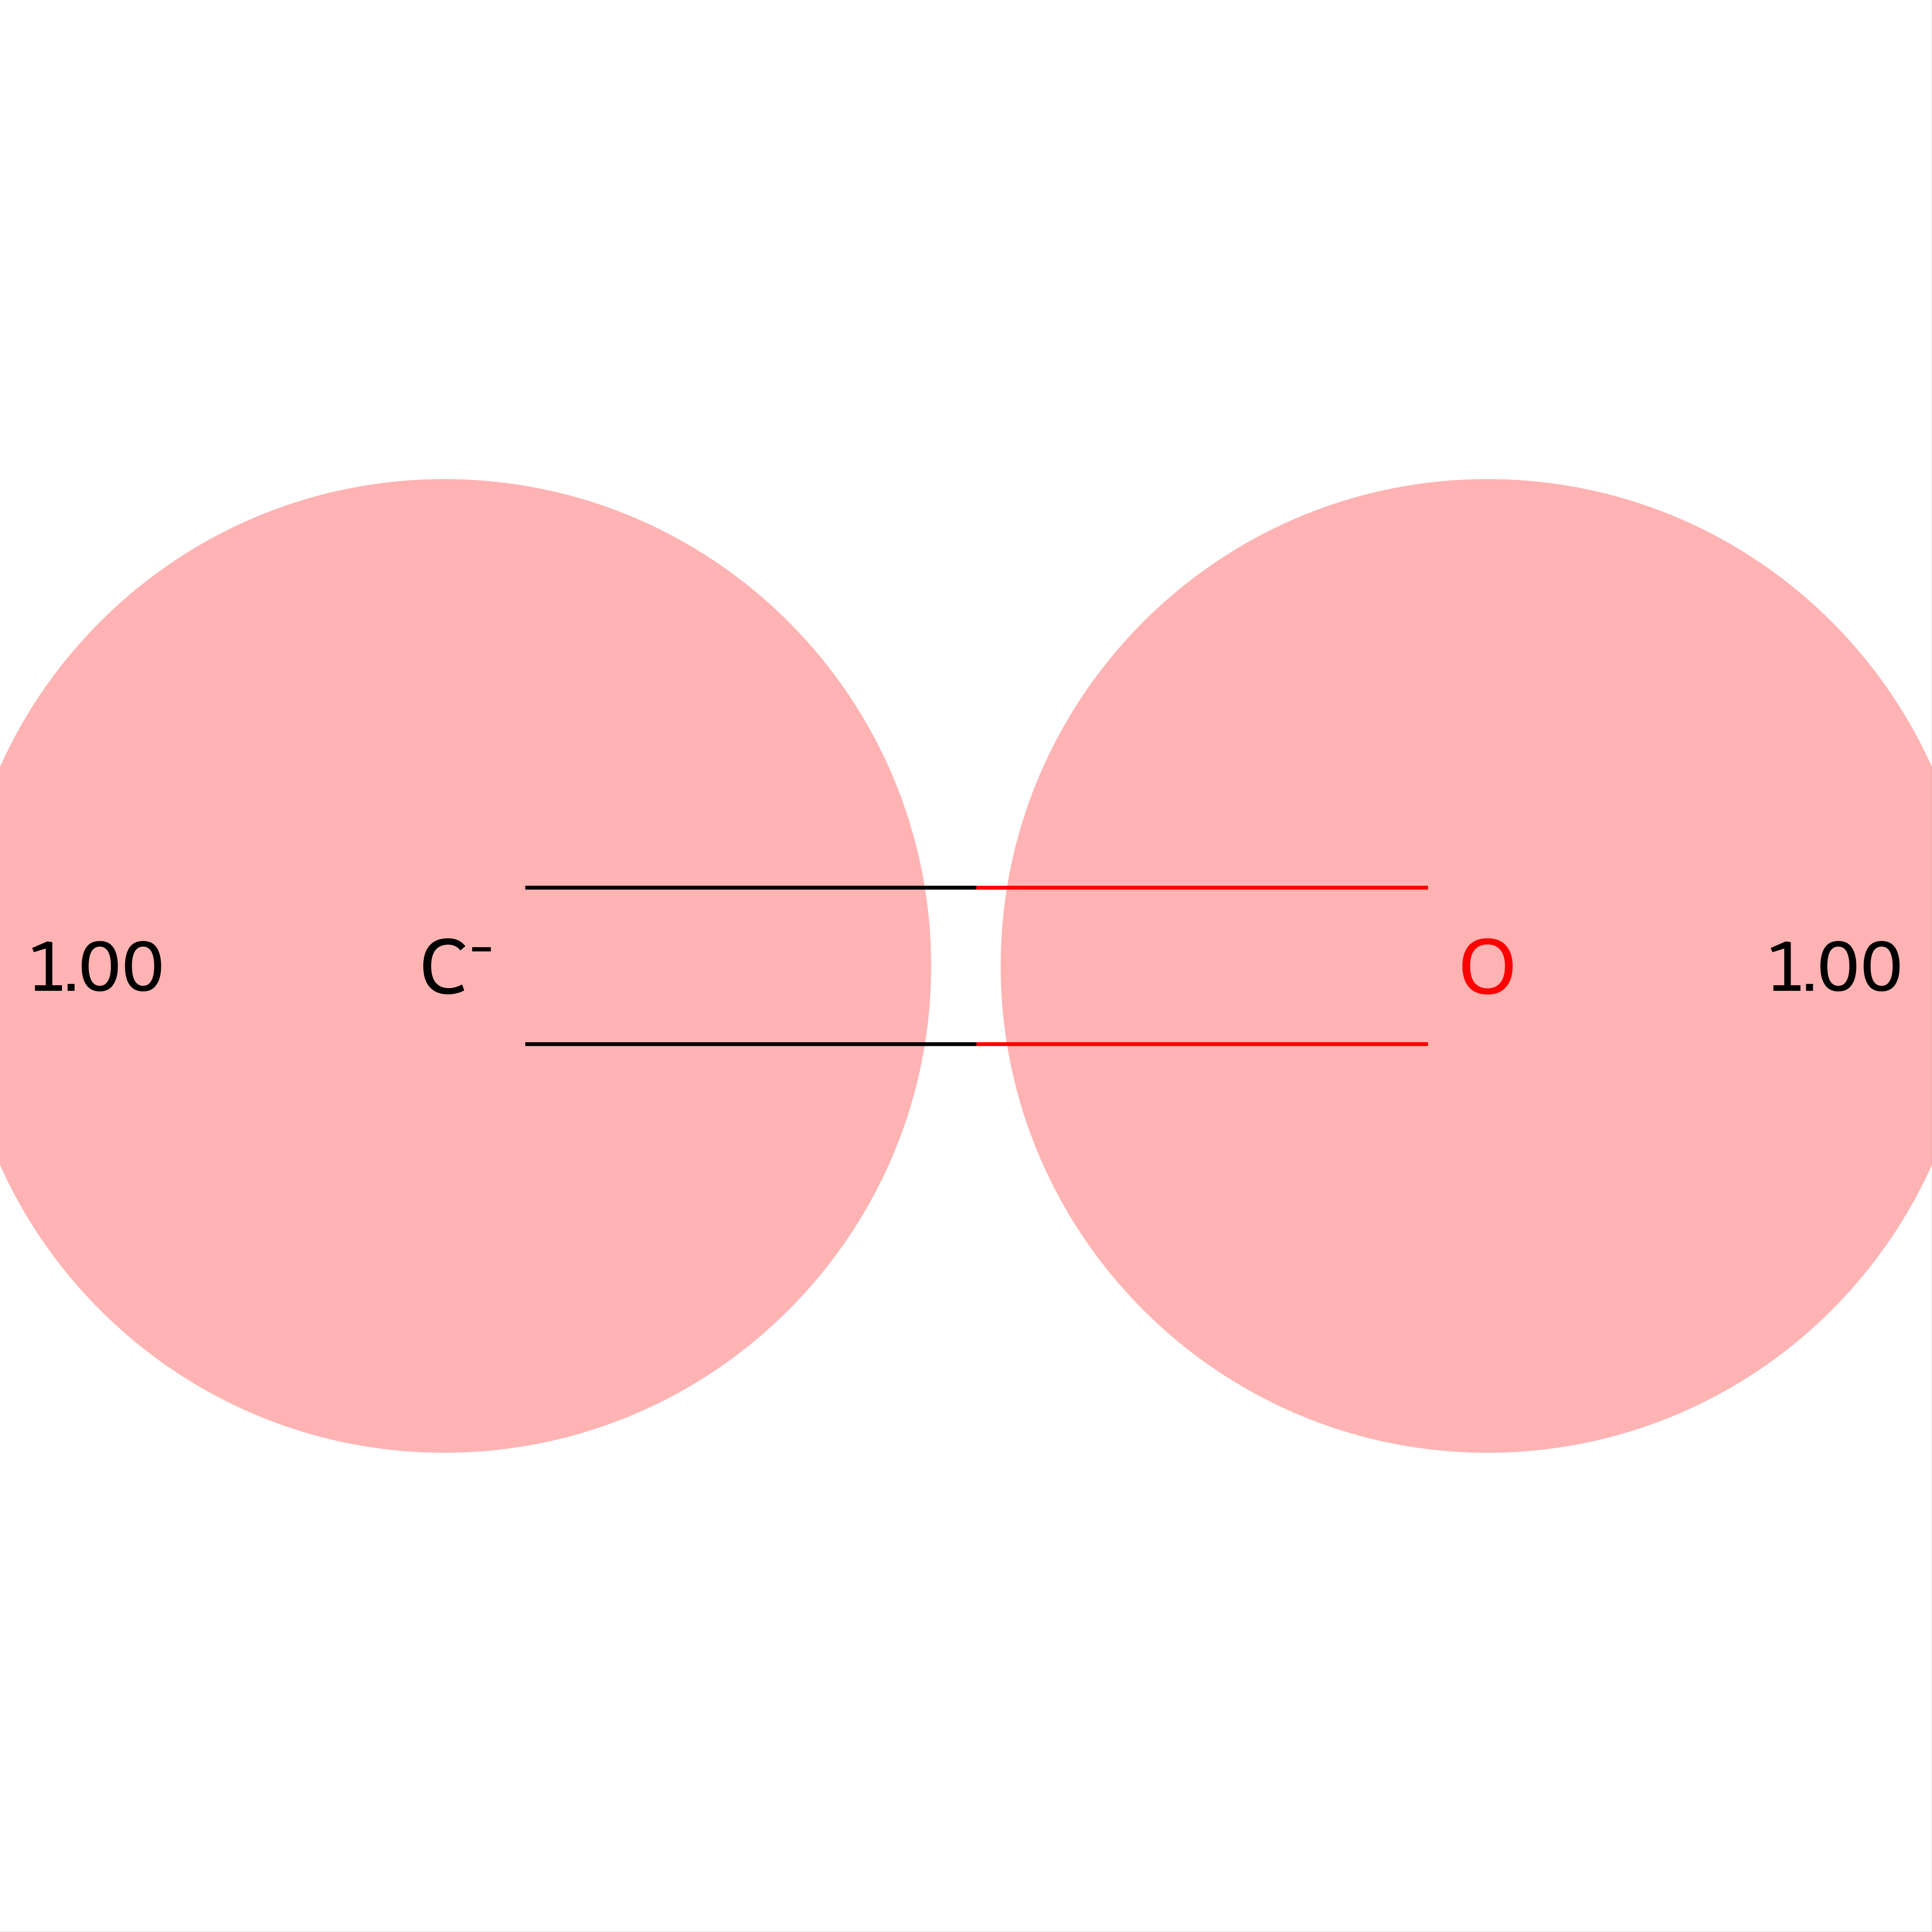

In [6]:
show_pge_attrib("[CH-]=O")

X tensor([[0., 0., 1., 1.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [0., 0., 1., 1.]])
Output tensor([[  86.9639],
        [-133.8509],
        [-133.8509],
        [  86.9639]], grad_fn=<AddmmBackward0>)
Model prediction: 1.0


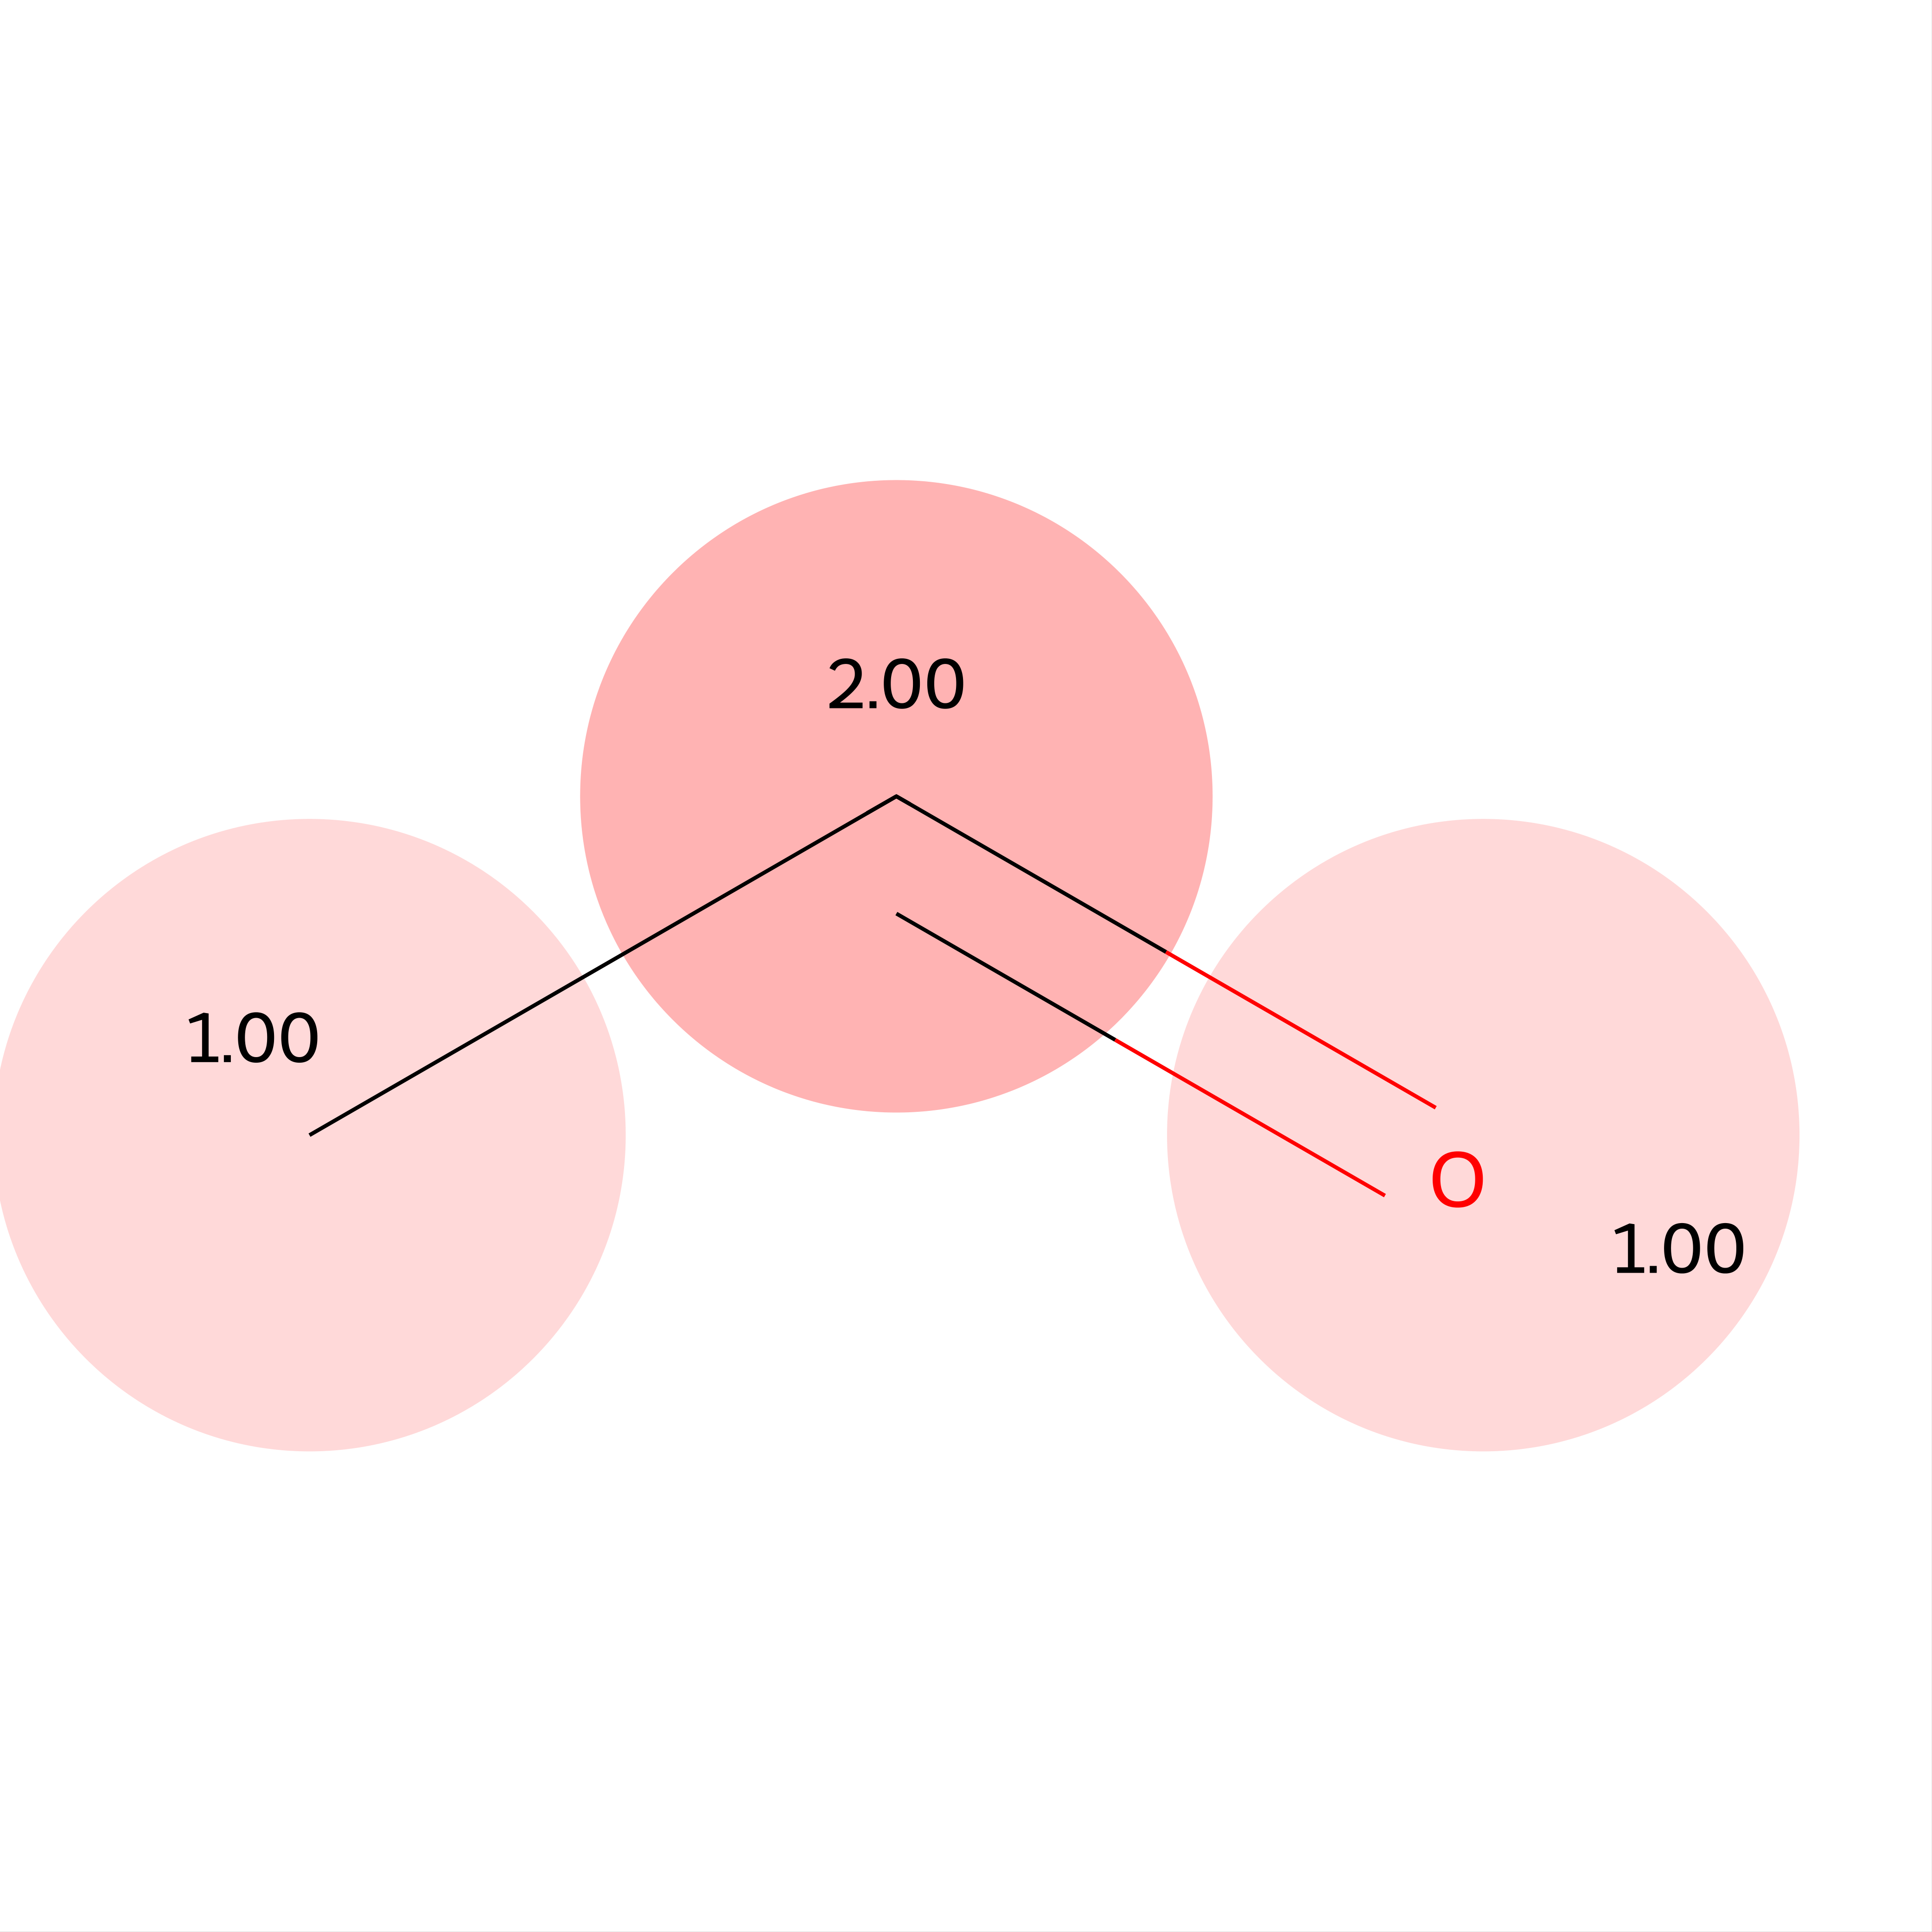

In [7]:
show_pge_attrib("C[CH]=O")

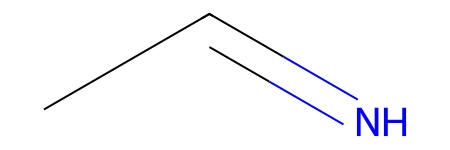

In [8]:
mol = Chem.MolFromSmiles("C[CH]=[NH]")
mol

X tensor([[0., 0., 0., 1.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 0., 1.]])
Output tensor([[-114.7234],
        [-119.8315],
        [-119.8315],
        [-114.7234]], grad_fn=<AddmmBackward0>)
Model prediction: 0.0


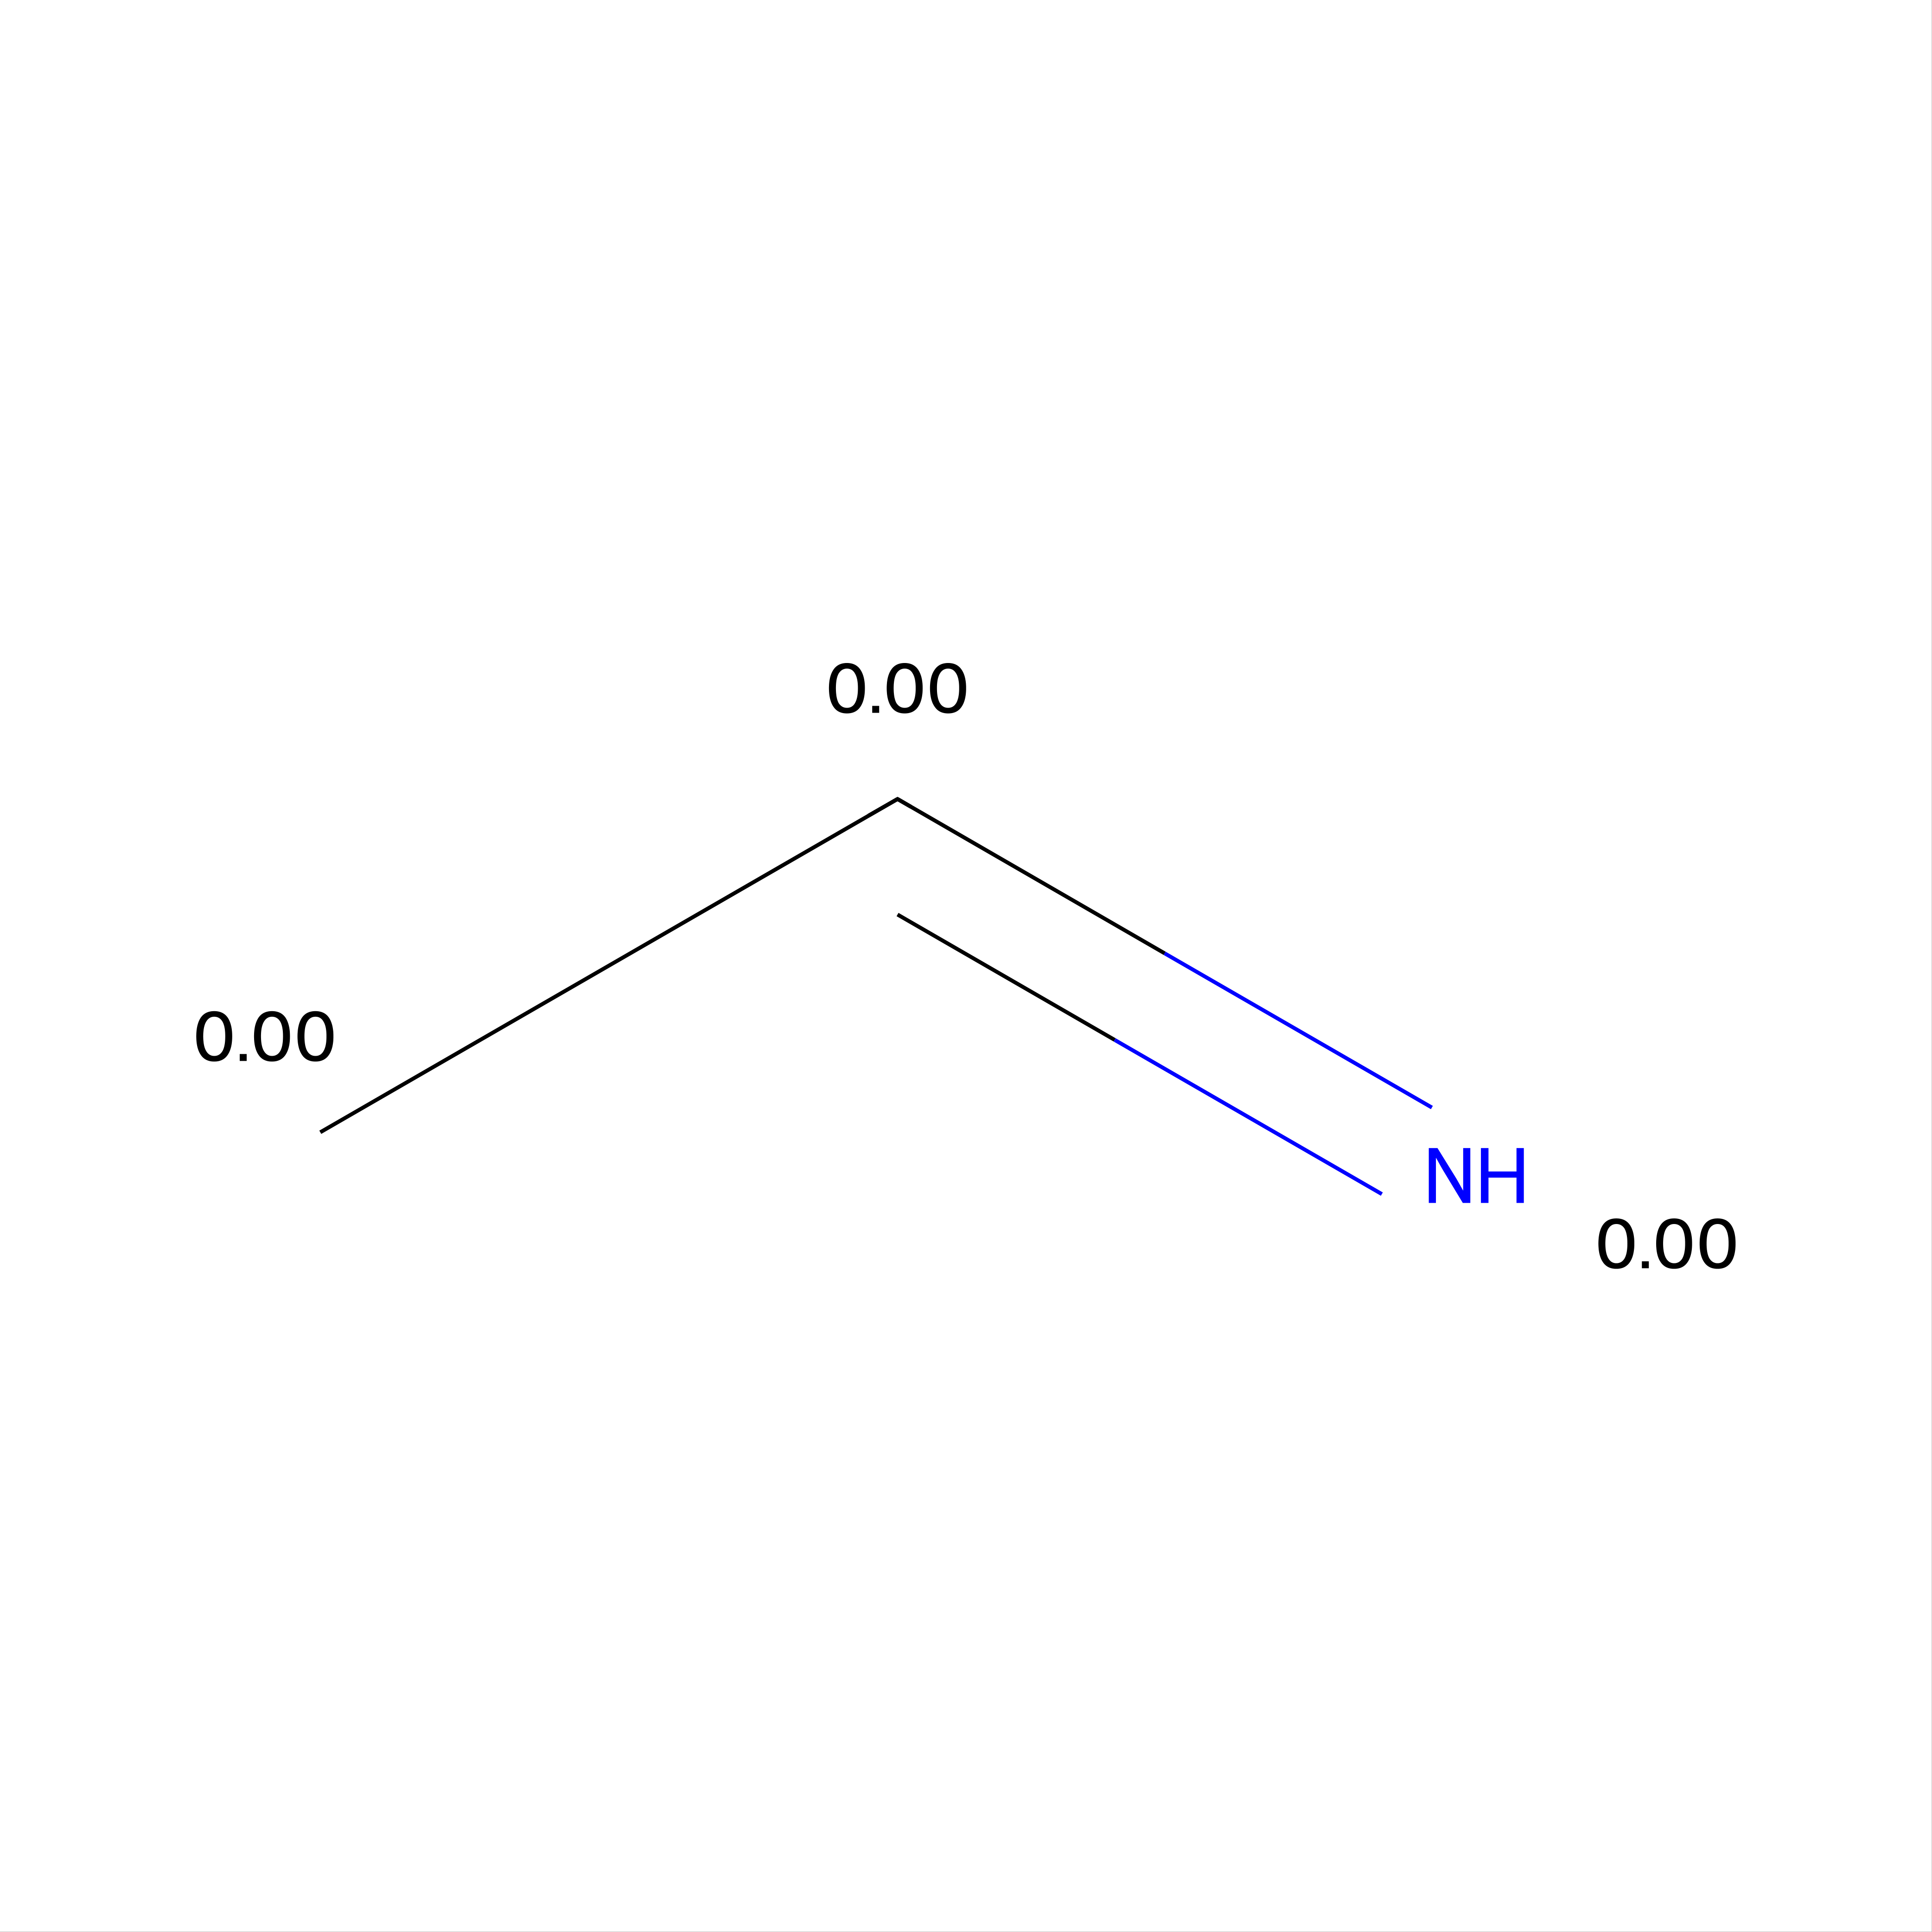

In [9]:
show_pge_attrib("C[CH]=[NH]")


In [20]:
inputs = torch.cartesian_prod(
    torch.tensor([0.0, 1.0]),
    torch.tensor([0.0, 1.0]),
    torch.tensor([0.0, 1.0]),
    torch.tensor([0.0, 1.0])
)

model_predicitons = pge_mlp(inputs)
#model_predicitons = pge_r1_mlp(inputs) # To see the same problem under r1


X tensor([[0., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 0., 1., 1.],
        [0., 1., 0., 0.],
        [0., 1., 0., 1.],
        [0., 1., 1., 0.],
        [0., 1., 1., 1.],
        [1., 0., 0., 0.],
        [1., 0., 0., 1.],
        [1., 0., 1., 0.],
        [1., 0., 1., 1.],
        [1., 1., 0., 0.],
        [1., 1., 0., 1.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])
Output tensor([[-120.2132],
        [-114.7234],
        [  54.3744],
        [  86.9639],
        [-119.8315],
        [-114.5416],
        [  59.6090],
        [  88.2223],
        [-132.7311],
        [-129.3377],
        [  46.6792],
        [  74.5373],
        [-133.8509],
        [-129.1755],
        [  51.4207],
        [  76.7645]], grad_fn=<AddmmBackward0>)


In [21]:
x_coords = inputs[:, :2].numpy()
y_coords = inputs[:, 2:].numpy()

x_coords = [f"{'A1' if x == 1 else ''} {'B1' if y == 1 else ''}".strip() for x, y in x_coords]
y_coords = [f"{'A1' if x == 1 else ''} {'B1' if y == 1 else ''}".strip() for x, y in y_coords]

predictions = model_predicitons.detach().squeeze().numpy()

In [22]:
preds_df = pd.DataFrame({
    "x": x_coords,
    "y": y_coords,
    "prediction": predictions
})

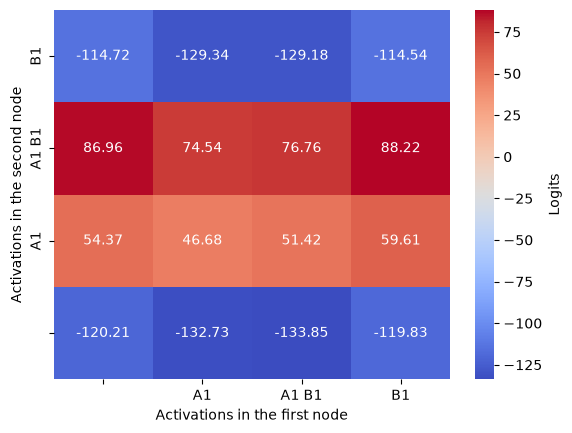

In [23]:
pivot = preds_df.pivot(index="y", columns="x", values="prediction")

# Sort the pivot
pivot = pivot.reindex(sorted(pivot.index, reverse=True), columns=sorted(pivot.columns))

path = pathlib.Path("notebook_artifacts/pg_heuristic")
path.mkdir(parents=True, exist_ok=True)

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Logits"},
            )

# Annotate x, y
plt.xlabel("Activations in the first node")
plt.ylabel("Activations in the second node")

plt.savefig("notebook_artifacts/pg_heuristic/heatmap.png", dpi=300)

In [14]:
r2_results_positive = pd.read_csv(
    "artifacts/explainability_method_tester/R2/MoleculeODetector/positive_explainability_results.csv"
)

pge_positive_fails = r2_results_positive.dropna(subset=["PG Explainer_auroc"])

pge_positive_fails = pge_positive_fails[pge_positive_fails['PG Explainer_auroc'] != 1]
pge_positive_fails_smiles = pge_positive_fails["SMILES"].tolist()

X tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [1., 1., 0., 0.],
        [1., 1., 0., 3.],
        [0., 3., 1., 1.],
        [0

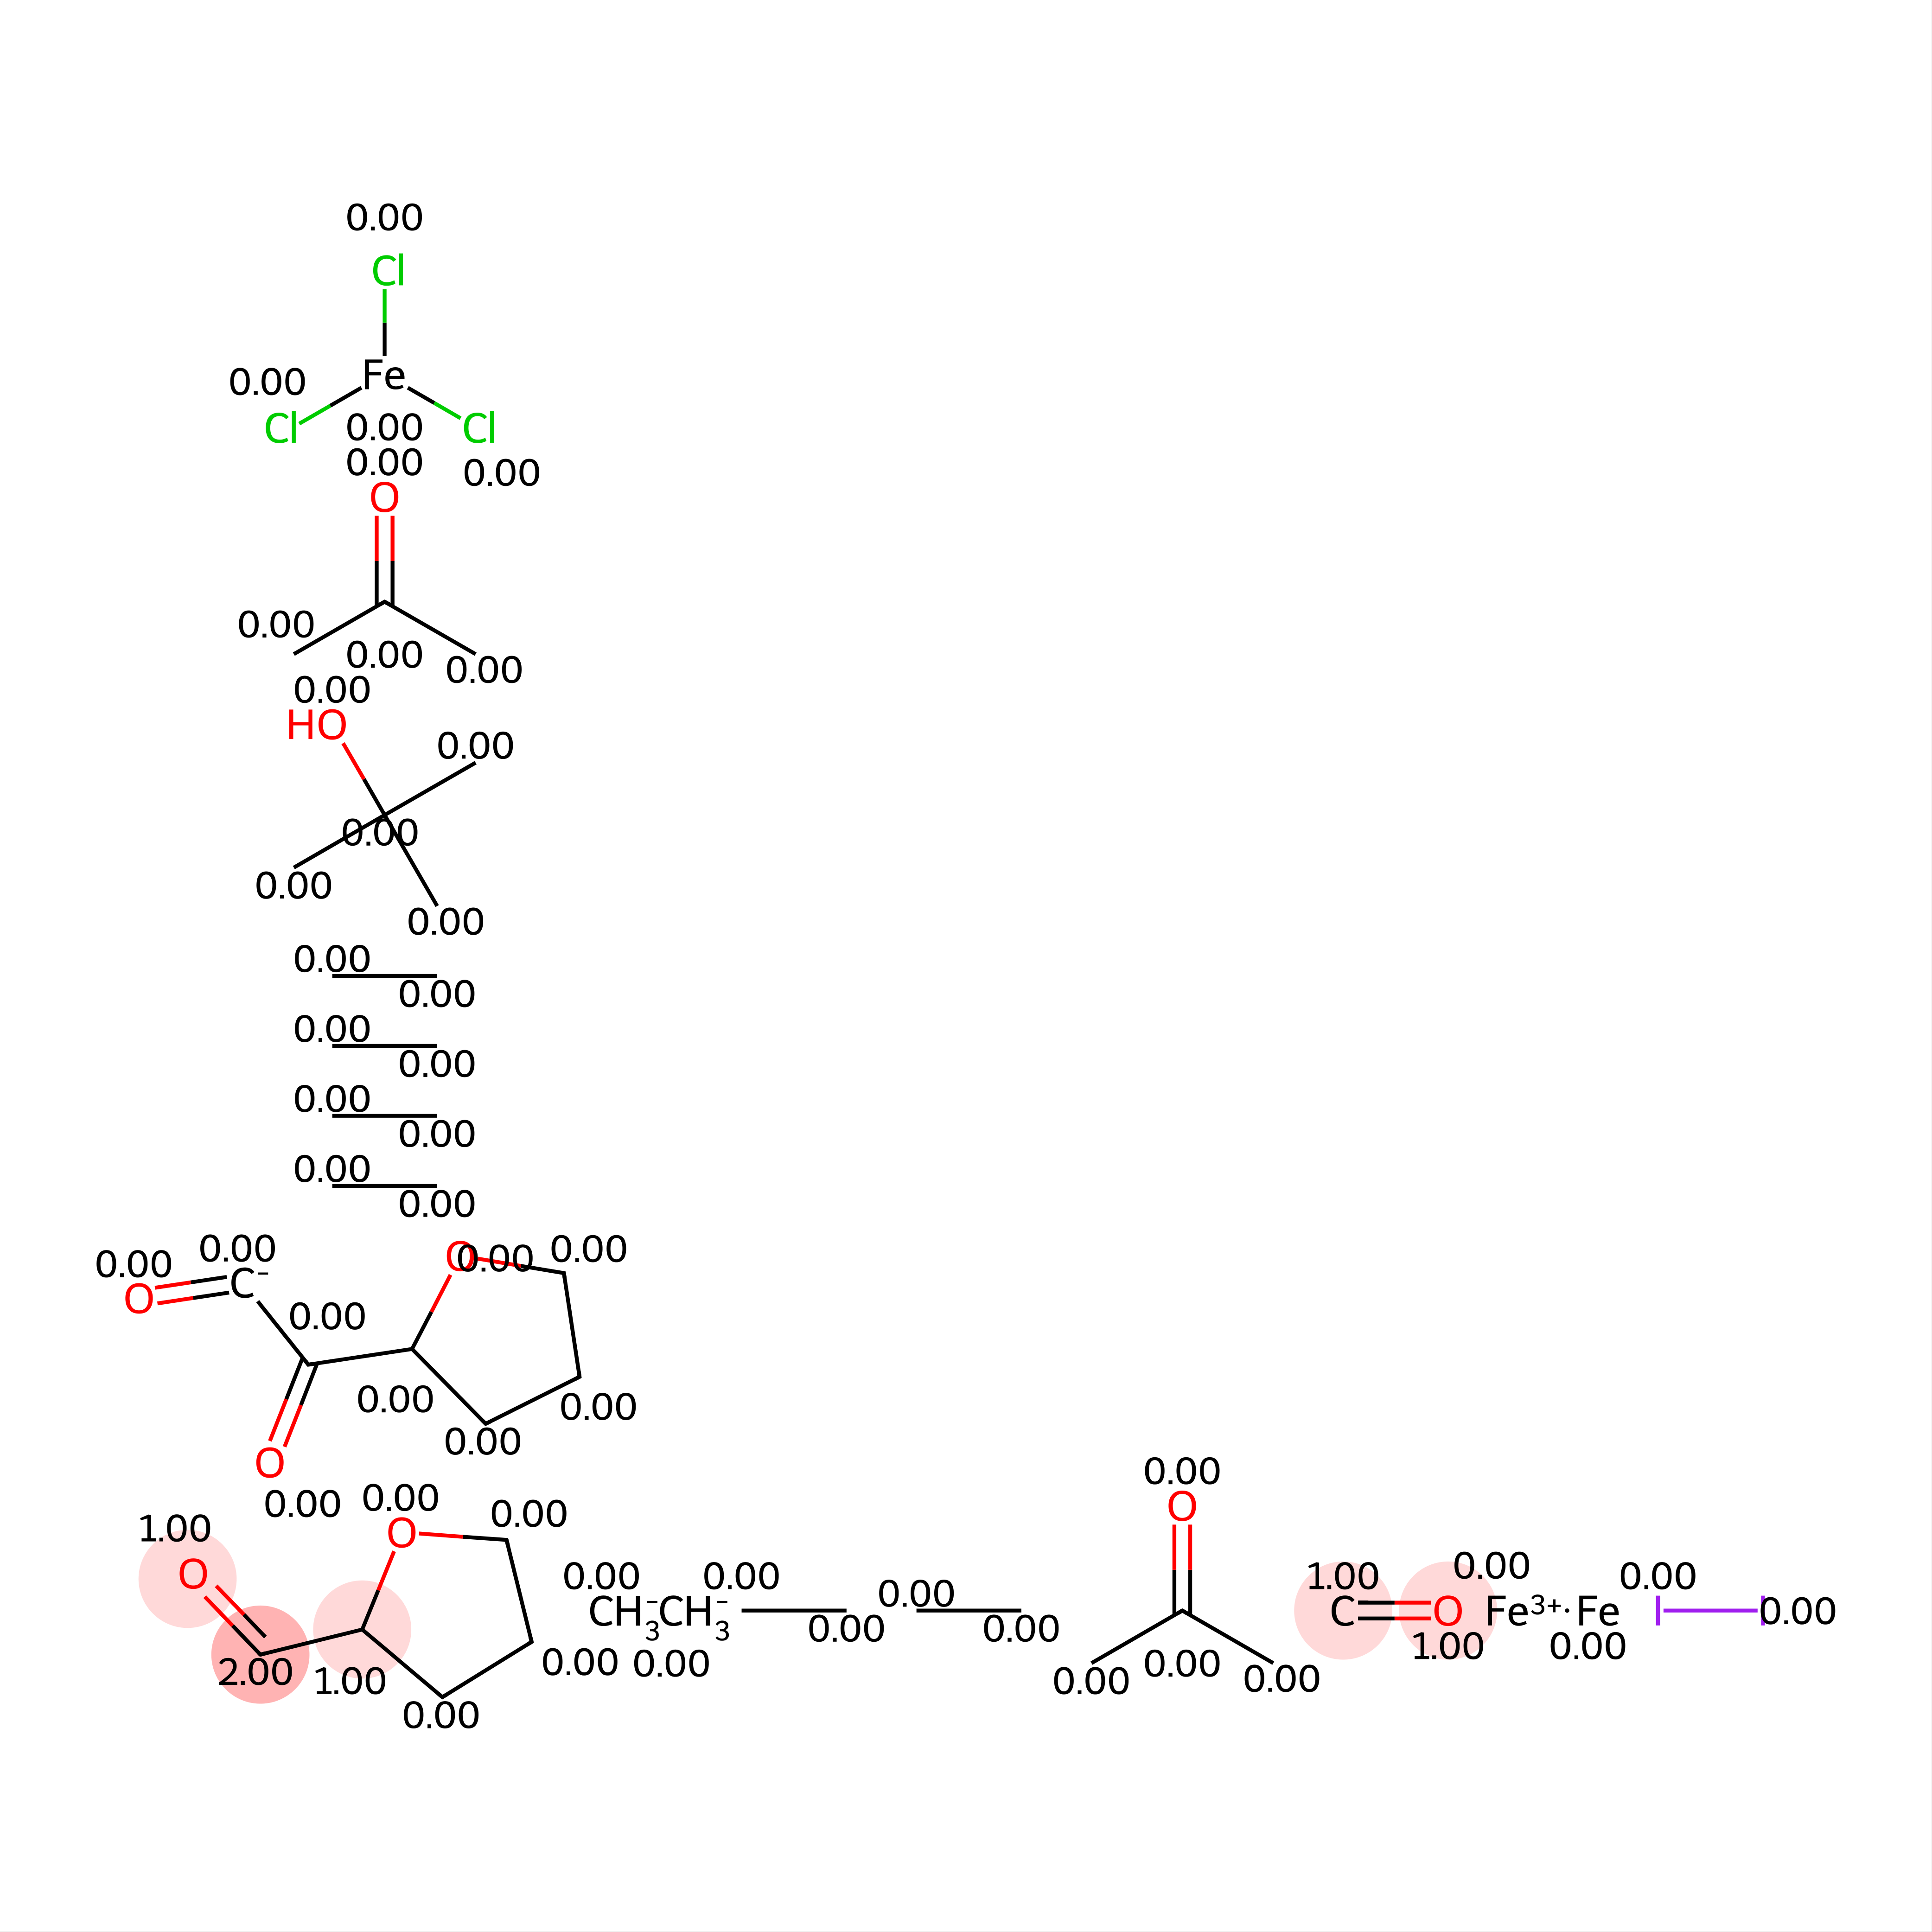

In [15]:
show_pge_attrib(pge_positive_fails_smiles[0])

X tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 3.],
        [0., 3., 0., 0.],
        [0., 3., 0., 0.],
        [0., 0., 0., 3.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 3.],
        [0., 3., 0., 0.],
        [0., 3., 0., 0.],
        [0., 0., 0., 3.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 3.],
        [0., 3., 0., 0.],
        [0., 3., 1., 1.],
        [1., 1., 0., 3.],
        [1., 1., 0., 0.],
        [0., 0., 1., 1.],
        [0., 3., 0., 0.],
        [0., 0., 0., 3.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 3.],
        [0., 3., 0., 0.],
        [0

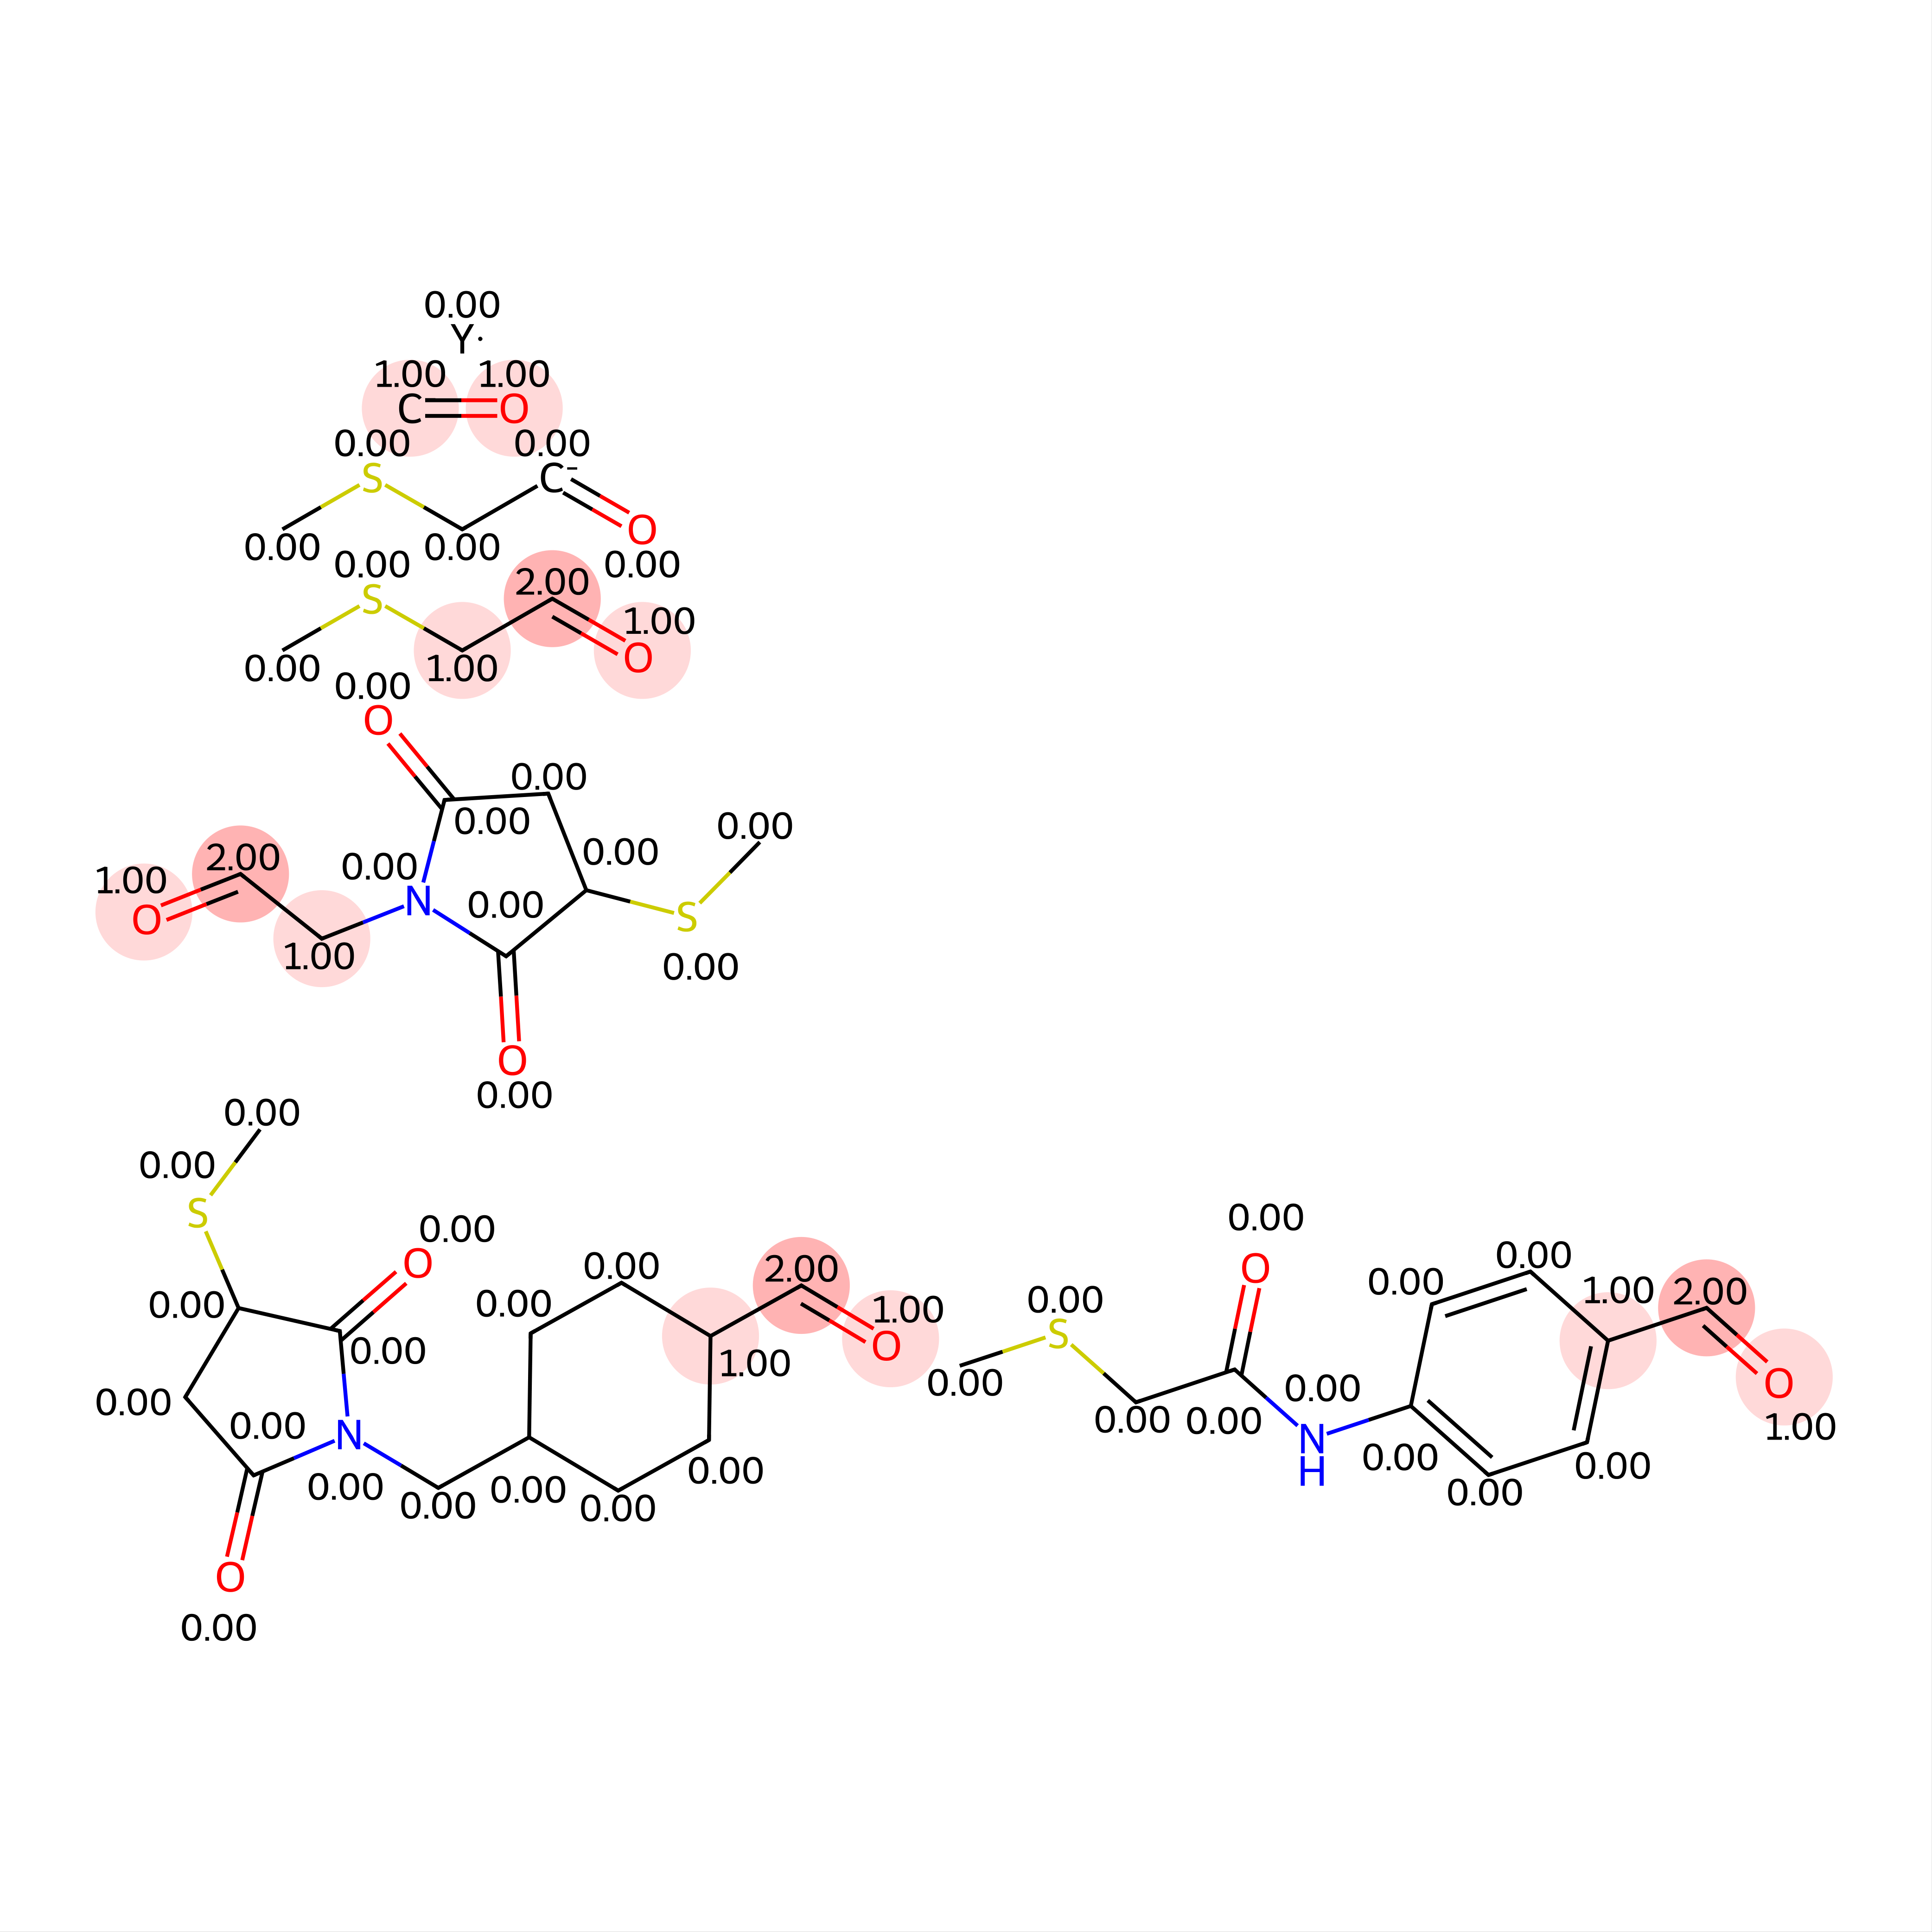

In [16]:
show_pge_attrib(smile=pge_positive_fails_smiles[1])

In [17]:
from statistics import mean


def calculate_number_of_positive_nodes(smiles: str, model) -> int:
    mol = Chem.MolFromSmiles(smiles)
    x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

    _, activations = model(x, edge_features, edge_index, dump_activations=True)

    activations = activations[-1]

    # Get number of non-zeros
    activations = torch.sum(activations, dim=1)
    activation_number: int = torch.sum(activations != 0.0).item()

    return activation_number


def get_avg_activation_count(positive_df, negative_df, model) -> tuple[float, float]:
    positive_samples = positive_df.dropna(subset=["PG Explainer_auroc"])["SMILES"].tolist()
    negative_samples = negative_df.dropna(subset=["PG Explainer"])["SMILES"].tolist()

    positive_counts = [calculate_number_of_positive_nodes(smile, model) for smile in positive_samples]
    negative_counts = [calculate_number_of_positive_nodes(smile, model) for smile in negative_samples]

    return mean(positive_counts), mean(negative_counts)


9


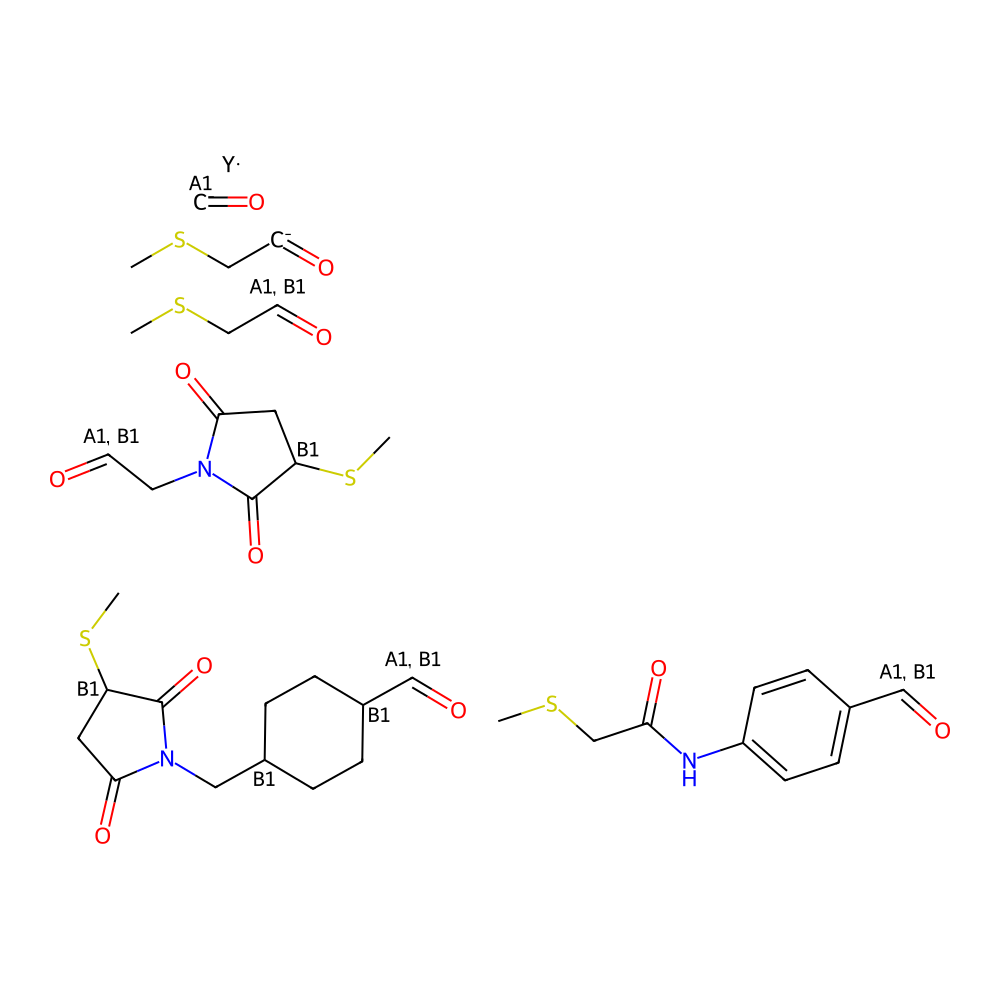

In [18]:
# Making sure it works properly
from mpnn import visualize_activations

print(calculate_number_of_positive_nodes(
    pge_positive_fails_smiles[1],
    MoleculeODetector()
))  # Should be 9

mol = Chem.MolFromSmiles(pge_positive_fails_smiles[1])
x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

_, activations = MoleculeODetector()(x, edge_features, edge_index, dump_activations=True)

visualize_activations(mol, activations[-1], layer_number=1)

In [19]:
pattern_positive_means = []
pattern_negative_means = []

for model, _, _ in krfp_models:
    pge_positive = pd.read_csv(
        f"artifacts/explainability_method_tester/R2/{model.__class__.__name__}/positive_explainability_results.csv")
    pge_negative = pd.read_csv(
        f"artifacts/explainability_method_tester/R2/{model.__class__.__name__}/negative_explainability_results.csv")

    positive, negative = get_avg_activation_count(
        positive_df=pge_positive,
        negative_df=pge_negative,
        model=model
    )

    pattern_positive_means.append(positive)
    pattern_negative_means.append(negative)

KeyboardInterrupt: 

In [20]:
print("Positive", pattern_positive_means)
print("Negative", pattern_negative_means)

Positive []
Negative []


In [21]:
df = pd.DataFrame({
    "Positive": pattern_positive_means,
    "Negative": pattern_negative_means
})
df.index.name = "index"
df.to_csv("notebook_artifacts/pg_heuristic/activation_means.csv")

In [22]:
import numpy as np

from sklearn.metrics import roc_auc_score

from highlight_smarts import highlight_atoms_in_mol


# This serves as a loose upper bound. (favorable to pge)
def calculate_ideal_auroc(smiles: str, model, model_post_smarts: str) -> float:
    mol = Chem.MolFromSmiles(smiles)
    x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

    _, activations = model(x, edge_features, edge_index, dump_activations=True)

    activations = activations[-1]
    activations = torch.sum(activations, dim=1)  # (N,)
    activations = [act.item() for act in activations]

    gt_attributed_node_idxs = highlight_atoms_in_mol(mol, model_post_smarts)
    gt_attribution = np.zeros(mol.GetNumAtoms(), dtype=int)

    for node in gt_attributed_node_idxs:
        gt_attribution[node] = 1

    upper_bound_attributions = np.zeros(mol.GetNumAtoms(), dtype=int)

    edge_left, edge_right = edge_index[0], edge_index[1]

    for node in gt_attributed_node_idxs:
        # Check if node is activated, at all
        if activations[node] != 0:
            # Assume the ideal case that PGE can somehow distinguish for all activated nodes if they belong to the structure or not.
            # This is not true, but we are establishing a simple upper bound.
            # Hence, we assume that all edges coming from this node are properly attributed -- meaning that, in neighbour interpolation, all neighbours of this node (and this node) are properly attributed
            is_outgoing_edge = edge_left == node
            neighbours = edge_right[is_outgoing_edge]

            # We assume that activated node and all its neighbours -- somehow -- get properly attributed
            upper_bound_attributions[node] = 1
            upper_bound_attributions[neighbours] = 1
            upper_bound_attributions = upper_bound_attributions & gt_attribution

    return roc_auc_score(
        y_true=gt_attribution,
        y_score=upper_bound_attributions
    )


print("Ideal auroc for a simple pattern", calculate_ideal_auroc(
    smiles=pge_positive_fails_smiles[1],
    model=krfp_models[11][0],
    model_post_smarts=krfp_models[11][2],
))


Ideal auroc for a simple pattern 1.0


In [23]:
from tqdm.notebook import tqdm

pattern_positive_aurocs = []

for model, _, post_smarts in tqdm(krfp_models):
    pge_positive = pd.read_csv(
        f"artifacts/explainability_method_tester/R2/{model.__class__.__name__}/positive_explainability_results.csv")
    pge_negative = pd.read_csv(
        f"artifacts/explainability_method_tester/R2/{model.__class__.__name__}/negative_explainability_results.csv")

    positive_smiles = pge_positive.dropna(subset=["PG Explainer_auroc"])["SMILES"].tolist()

    aurocs = [calculate_ideal_auroc(smile, model, post_smarts) for smile in positive_smiles]
    mean_auroc = mean(aurocs)

    pattern_positive_aurocs.append(mean_auroc)

print(pattern_positive_aurocs)

  0%|          | 0/14 [00:00<?, ?it/s]

[0.6510221479189203, 0.7084007094600315, 0.59375, 0.6137955173854218, 0.6312951161741485, 1.0, 0.7527328499169346, 0.7873902658602258, 0.8563714870488658, 1.0, 1.0, 1.0, 1.0, 1.0]


In [24]:
df = pd.DataFrame(
    {
        "mean_auroc": pattern_positive_aurocs,
    }
)

df.index.name = "index"

df.to_csv("notebook_artifacts/pg_heuristic/mean_aurocs.csv")